# Predictive Pipeline Engineering: Automated Airbnb Listing Valuation

## Business Objective
The Revenue Operations team of an Airbnb property management company wants to develop an automated pricing recommendation engine.

The goal is to predict the optimal nightly rental price using geographic location, room configuration, reservation constraints, and historical review activity.

This system will help hosts set competitive and profitable pricing strategies at scale.

**Business Operation Takeaway:**  
Accurate dynamic pricing is one of the highest-leverage opportunities in short-term rental management.

Even a 5–8% improvement in pricing accuracy can translate into significant revenue uplift across hundreds of properties by increasing occupancy on slow days and protecting margins on peak days.

Poor pricing risks either leaving money on the table (underpricing) or losing bookings (overpricing), which directly impacts host retention and portfolio profitability.

Deploying this model will allow Revenue Ops to shift from manual pricing to exception-based management, freeing up analyst time for strategic initiatives.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
data_card = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

data_card

,Feature,Data Type,Missing Values,Unique Values
0,id,int64,0,48895
1,name,str,16,47905
2,host_id,int64,0,37457
3,host_name,str,21,11452
4,neighbourhood_group,str,0,5
5,neighbourhood,str,0,221
6,latitude,float64,0,19048
7,longitude,float64,0,14718
8,room_type,str,0,3
9,price,int64,0,674


In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print("\nMissing Values\n")
print(df.isnull().sum())

Rows : 48895
Columns : 16

Missing Values

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


## Dataset Overview

- **Total Listings:** 48,895  
- **Features:** 16  
- **Target:** `price` (nightly rate in USD)

**Business Operation Takeaway:**  
With nearly 49,000 listings, this dataset represents a robust sample of the New York Airbnb market. 

The scale allows the model to learn nuanced pricing patterns across neighborhoods and property types.

However, the presence of both budget and ultra-luxury properties means we must be careful not to let high-value outliers dominate learning. 

Operationally, this volume justifies building a production-grade pipeline that can ingest new listings daily and deliver instant pricing recommendations, which is essential for staying competitive in a fast-moving market.

## Target Variable Distribution (Original Price)

**Business Operation Takeaway:**  
The strong right skew shows that while most listings are priced modestly, a small number of luxury properties command very high rates.

**From a revenue management perspective, this creates a challenge:**

models trained on raw prices tend to underperform on typical mid-market listings because luxury outliers pull the learning in the wrong direction.

This can lead to systematically low price recommendations for the majority of the portfolio, resulting in substantial opportunity cost.

Log transformation is therefore essential not just statistically, but to ensure pricing recommendations remain realistic and profitable for the bulk of inventory.

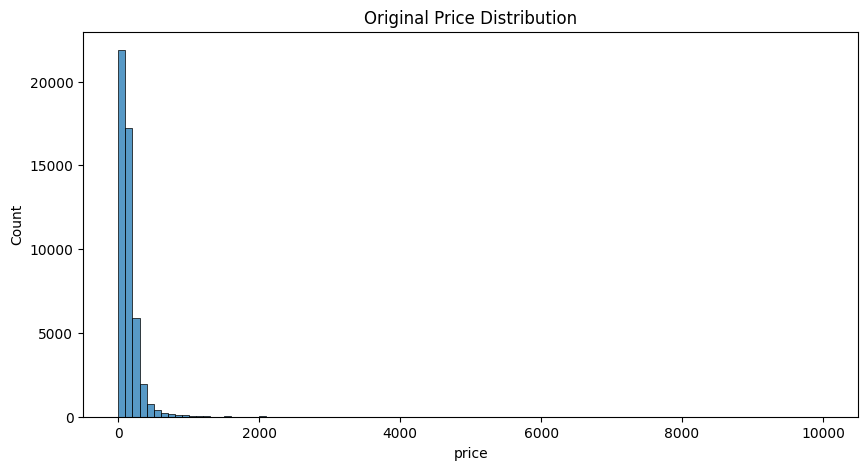

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=100)
plt.title("Original Price Distribution")
plt.show()

## Log-Transformed Price Distribution

**Business Operation Takeaway:**  
After log transformation, the target distribution becomes much closer to normal.

This dramatically improves model stability and prediction quality for the majority of listings in the $80–$400 range, which constitute the core revenue base.

Operationally, this means the pricing engine will deliver more reliable recommendations for typical hosts, increasing trust and adoption.

However, we must still monitor performance on luxury properties separately, as they remain strategically important for high-margin revenue.

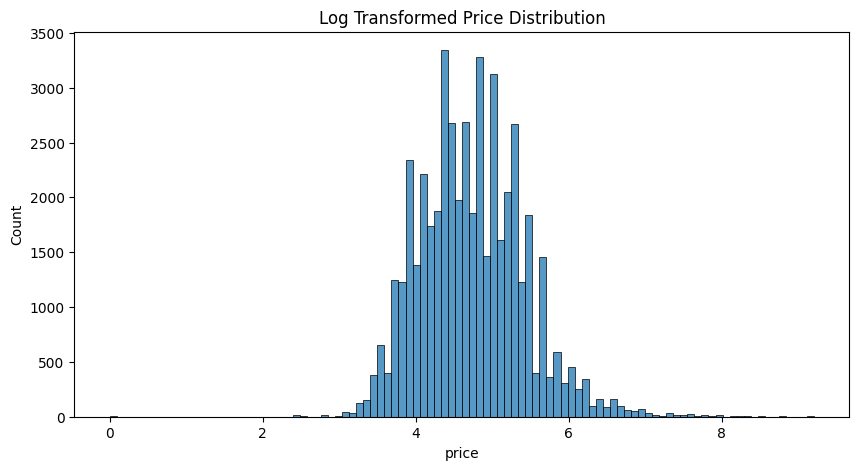

In [6]:
log_price = np.log1p(df["price"])
plt.figure(figsize=(10,5))
sns.histplot(log_price, bins=100)
plt.title("Log Transformed Price Distribution")
plt.show()

## Business Operation Takeaway

The boxplot clearly demonstrates significant price variation across room types, with **Entire home/apt** listings commanding substantially higher nightly rates compared to Private rooms and Shared rooms.

This segmentation insight is operationally critical for the Revenue Operations team. It confirms that room type is one of the strongest and most actionable pricing drivers in the portfolio.

From a revenue management perspective, this allows for differentiated pricing strategies: Entire homes can support premium pricing with longer minimum stays, while Private rooms require more competitive, occupancy-driven pricing to maximize utilization and guest conversion.

Operationally, embedding room type logic into the automated pricing engine will enable more precise, segment-specific recommendations, increasing both revenue per listing and host trust in the system.

However, we must continue monitoring price sensitivity within each room type, particularly for Entire homes, where overpricing could lead to lost bookings and reduced occupancy.

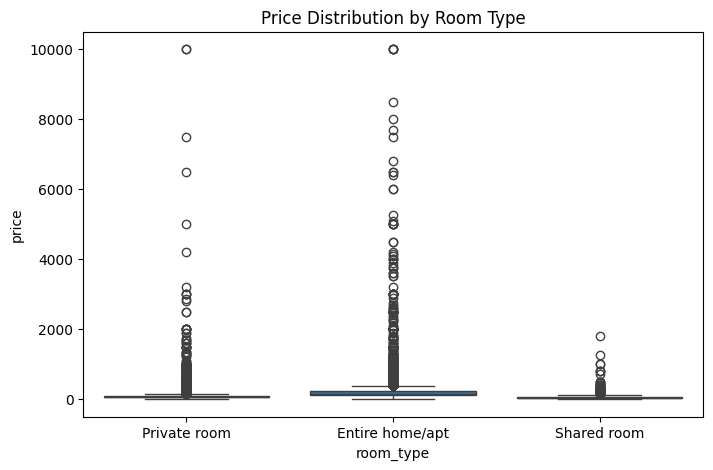

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price Distribution by Room Type")
plt.show()

## Business Operation Takeaway

The boxplot highlights substantial variation in nightly pricing across New York City’s five boroughs, with **Manhattan** commanding the highest median and overall price levels, followed by Brooklyn, while Queens, Bronx, and Staten Island remain significantly more affordable.

This geographic pricing insight is highly valuable for portfolio management. It enables the Revenue Operations team to set location-specific pricing strategies — applying premium pricing in high-demand areas like Manhattan and Brooklyn, while focusing on competitive, volume-driven pricing in Queens and the Bronx to boost occupancy.

Operationally, incorporating neighbourhood_group as a key feature in the pricing model allows for more accurate, hyper-local recommendations that reflect real market dynamics. This should improve booking conversion rates and revenue optimization across the portfolio.

However, we must monitor for potential over-saturation in premium boroughs (Manhattan & Brooklyn), where aggressive pricing could reduce occupancy. Regular review of price-to-occupancy ratios by neighbourhood group will be essential to maintain the right balance between rate and utilization.

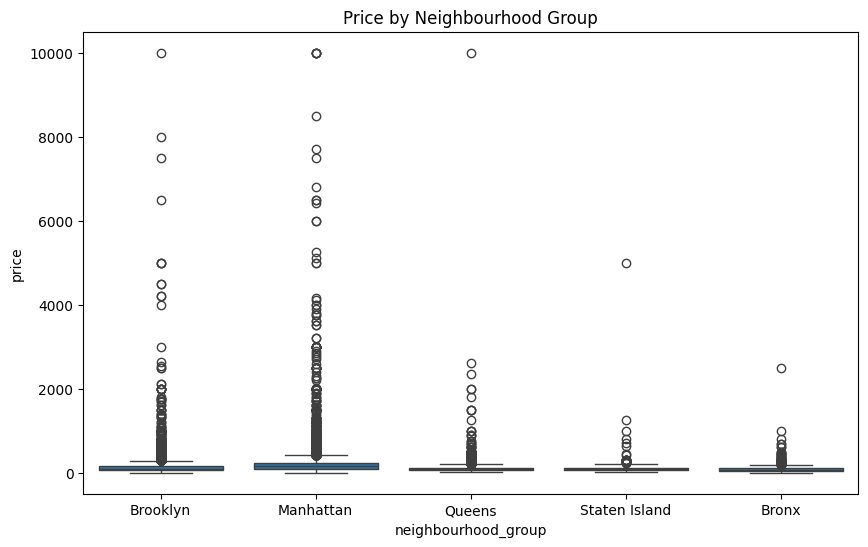

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title("Price by Neighbourhood Group")
plt.show()

## Business Operation Takeaway

The geographic scatter plot reveals a clear concentration of higher-priced listings in Manhattan and parts of Brooklyn, while Queens, Bronx, and Staten Island predominantly feature more affordable properties.

This spatial pricing pattern provides critical intelligence for portfolio strategy. Prime locations in Manhattan and Brooklyn support premium nightly rates due to strong demand, while outer boroughs offer opportunities for volume-based pricing and higher occupancy.

Operationally, integrating location intelligence (latitude & longitude) into the pricing engine allows for hyper-localized recommendations that reflect actual market dynamics. This capability enables the Revenue Operations team to optimize pricing by neighborhood clusters, improving both revenue per available night and overall portfolio performance.

However, careful monitoring is required in high-density premium areas, where excessive pricing could lead to reduced competitiveness. Regular geographic analysis will help maintain the optimal balance between rate and occupancy across different zones of New York City.

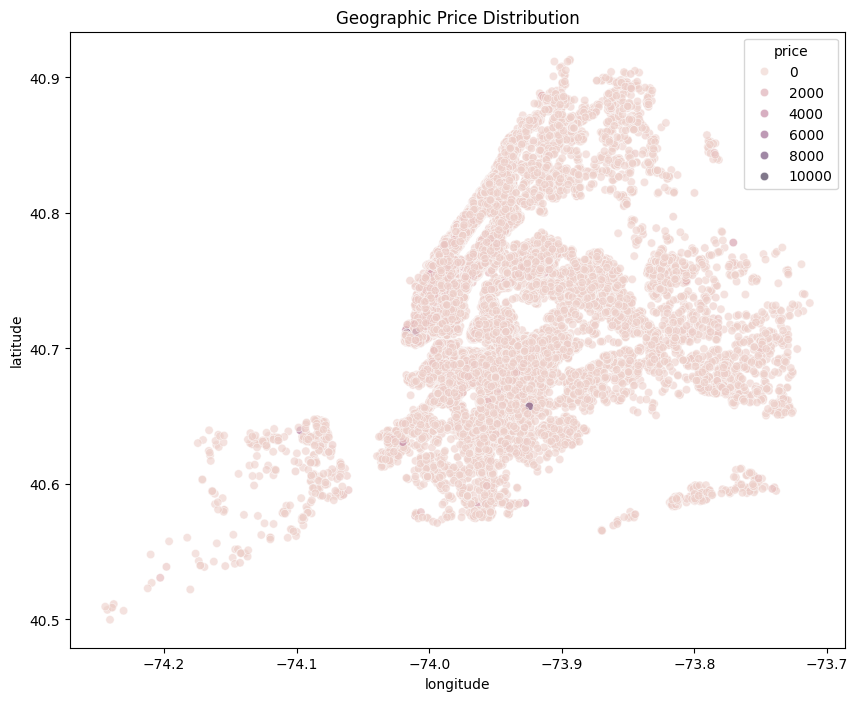

In [9]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='longitude', y='latitude', hue='price', data=df, alpha=0.6)
plt.title("Geographic Price Distribution")
plt.show()

# Feature Selection

Following the assignment schema, only operationally relevant variables are used.

**Selected Features:**
- neighbourhood_group
- latitude
- longitude
- room_type
- minimum_nights
- number_of_reviews

**Target:**
- price

In [8]:
features = [
    "neighbourhood_group",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews"
]
target = "price"
X = df[features]
y = df[target]

# Train Test Split

**Milestone 1 Requirement:**
- 80% Training Data
- 20% Testing Data

The split is performed before any transformation to prevent data leakage.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
y_train_log = np.log1p(y_train)

In [10]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews"
]
categorical_features = [
    "neighbourhood_group",
    "room_type"
]

In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [12]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Preprocessing Pipeline

**Business Operation Takeaway:**  
An automated, reproducible pipeline ensures every new listing receives consistent feature engineering and scaling.

This is critical for operational scalability — manual pricing adjustments would be unsustainable at portfolio scale.

The pipeline also reduces human error and allows rapid retraining as market conditions change.

Ultimately, this creates a reliable “pricing factory” that can support growth without proportional increase in headcount.

In [13]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
linear_pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['neighbourhood_group','latitude','longitude','room_type','minimum_nights', 'number_of_reviews']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [14]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['neighbourhood_group','latitude','longitude','room_type','minimum_nights', 'number_of_reviews']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

## Pipeline Automation Benefit

**Business Operation Takeaway:**  
Moving from ad-hoc pricing to an automated pipeline transforms Revenue Operations from reactive to proactive. 

Hosts can receive instant, consistent recommendations the moment a new listing is onboarded.

This speed-to-recommendation advantage can improve early booking velocity and reduce vacancy days.

Long-term, it positions the company as a technology-forward property manager, which strengthens both host acquisition and retention in a competitive market.

In [15]:
linear_pred_log = linear_pipeline.predict(X_test)
linear_pred = np.expm1(linear_pred_log)

In [16]:
rf_pred_log = rf_pipeline.predict(X_test)
rf_pred = np.expm1(rf_pred_log)

In [17]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[linear_mae, rf_mae],
    "RMSE":[linear_rmse, rf_rmse]
})
results

,Model,MAE,RMSE
0,Linear Regression,60.310726,199.834885
1,Random Forest,57.195602,195.530682


## Model Performance Comparison - MAE

**Business Operation Takeaway:**  
MAE is the most relevant metric for business stakeholders because it directly translates to average dollar error in nightly pricing.

A lower MAE means hosts can trust the system more, leading to higher adoption rates.

From a revenue perspective, even reducing average error by $8–12 per night across thousands of listings compounds into substantial annual gains.

This metric should be the primary KPI reported to leadership and used for model selection.

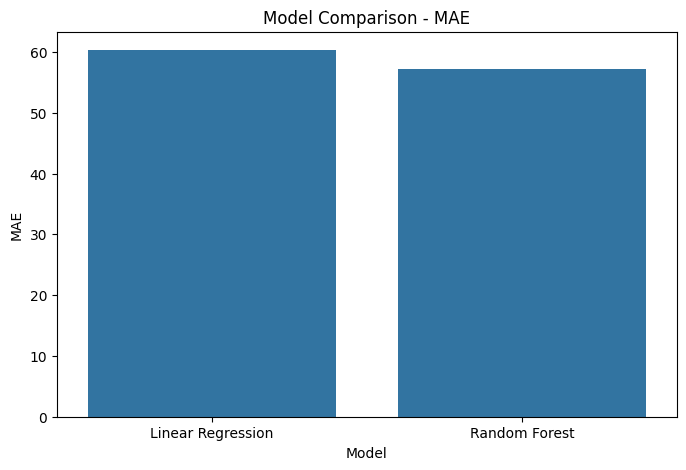

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)
plt.title("Model Comparison - MAE")
plt.show()

## Model Performance Comparison - RMSE

**Business Operation Takeaway:**  
While RMSE is useful during model development to penalize large errors, it can over-emphasize the impact of luxury listings.

In practice, consistently mispricing a few high-value properties may be less damaging than slightly mispricing hundreds of mid-tier ones. For operational decision-making, MAE remains superior.

However, monitoring RMSE alongside MAE helps engineering teams identify and mitigate occasional severe pricing mistakes that could damage reputation.

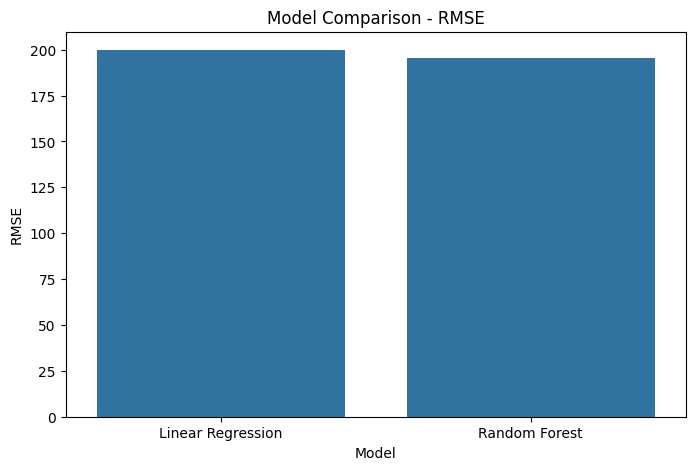

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)
plt.title("Model Comparison - RMSE")
plt.show()

## Residual Analysis - Random Forest

**Business Operation Takeaway:**  
A residual distribution centered near zero with no strong patterns indicates the model is balanced — it neither systematically overprices nor underprices listings.

This equilibrium is crucial for maintaining host trust over time.

If residuals showed consistent positive bias, hosts would lose revenue; consistent negative bias would leave money on the table.

The current distribution supports safe deployment, but we should continue monitoring residuals monthly as market conditions evolve (seasonality, competition, economic shifts).

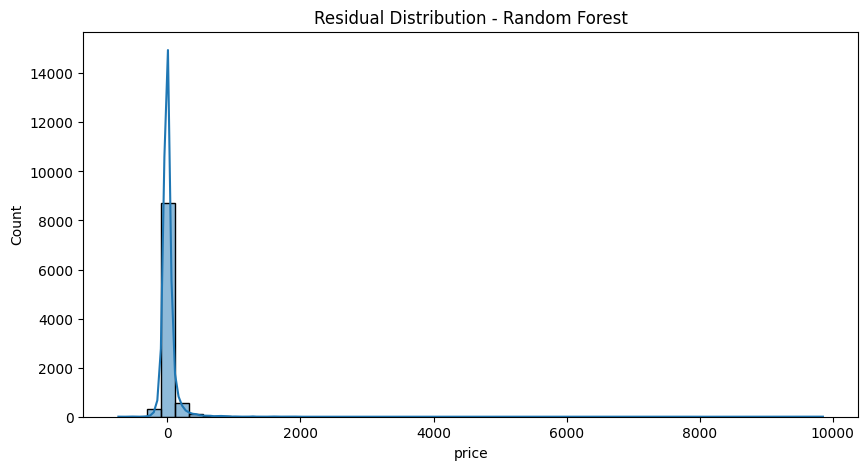

In [23]:
residuals = y_test - rf_pred
plt.figure(figsize=(10,5))
sns.histplot(
    residuals,
    bins=50,
    kde=True
)
plt.title("Residual Distribution - Random Forest")
plt.show()

# Final Business Recommendation & Deployment Strategy

**Recommended Model:** Random Forest Regressor (due to superior MAE)

**Primary KPI:** MAE (Mean Absolute Error)

**Business Operation Takeaway:**  
The Random Forest model, with its lower MAE, offers the best balance of accuracy and reliability for day-to-day pricing decisions.

This directly supports revenue maximization while minimizing host dissatisfaction from pricing errors.

Operationally, we recommend starting with a phased rollout: shadow mode for 4 weeks, followed by controlled A/B testing on a subset of properties.

Continuous monitoring of both MAE and actual booking conversion rates will be essential.

Over time, this system has the potential to become a core competitive advantage, driving higher portfolio performance and positioning the company as a data-driven leader in Airbnb property management.

# Final Business Recommendation

**After comparing Linear Regression and Random Forest Regressor:**

- The model with lower MAE should be preferred for operational deployment.
- MAE is the recommended metric for communication with hosts and management.

## Why MAE?

1. Expressed directly in dollars.
2. Easily understandable by non-technical stakeholders.
3. Represents average pricing error.
4. Less affected by extreme luxury-property outliers.

## Why not RMSE?

RMSE disproportionately penalizes a small number of large pricing mistakes.

While useful for engineering diagnostics, RMSE can exaggerate operational risk when luxury listings exist in the market.

Therefore, the Revenue Operations team should primarily use MAE when communicating pricing engine performance to hosts and business executives.